In [ ]:
# Met Strategic Acquisition Analysis Project: 
# Closing the Gap: Benchmarking the Met's Modern & Contemporary Acquisitions Against MoMA to Inform Tang Wing Strategy

In [ ]:
# 1. Imports
# 2. Load Met CSV
# 3. Load MoMA CSVs
# 4. Wikipedia scrape
# 5. Explore datasets
# 6. Clean data
# 7. Analysis
# 8. Visualizations

In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [3]:
met_url = "https://media.githubusercontent.com/media/metmuseum/openaccess/refs/heads/master/MetObjects.csv"
met_df = pd.read_csv(met_url, low_memory=False)
print(met_df.shape)
met_df.head()

(484956, 54)


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [ ]:
# 1. Filter met_df to only rows where Department == "Modern Art"
# 2. Select only the columns for analysis
# 3. Check the shape
# 4. Peek at the data

In [5]:
met_df["Department"].value_counts()

Department
Drawings and Prints                          172630
European Sculpture and Decorative Arts        43051
Photographs                                   37459
Asian Art                                     37000
Greek and Roman Art                           33726
Costume Institute                             31652
Egyptian Art                                  27969
The American Wing                             18532
Islamic Art                                   15573
Modern and Contemporary Art                   14696
Arms and Armor                                13623
Arts of Africa, Oceania, and the Americas     12367
Medieval Art                                   7142
Ancient Near Eastern Art                       6223
Musical Instruments                            5227
European Paintings                             2626
Robert Lehman Collection                       2586
The Cloisters                                  2340
The Libraries                                   534
N

In [6]:
met_modern = met_df[met_df["Department"] == "Modern and Contemporary Art"]
columns_needed = ["Object ID", "Department", "AccessionYear",
                  "Artist Display Name", "Artist Nationality",
                  "Artist Gender", "Object Name", "Culture"]

met_clean = met_modern[columns_needed]

print(met_clean.shape)
met_clean.head()

(14696, 8)


,Object ID,Department,AccessionYear,Artist Display Name,Artist Nationality,Artist Gender,Object Name,Culture
8710,9367,Modern and Contemporary Art,1976,George E. Ohr|Biloxi Art Pottery,American|,|,Vase,American
87696,141404,Modern and Contemporary Art,1986,Salvador Dalí,Spanish,NaN,Painting,Spanish
117750,208019,Modern and Contemporary Art,1991,Josef Hartwig|Heinz Nösselt,German|German,|,Chess set and board,German (Weimar)
118569,209045,Modern and Contemporary Art,NaN,NaN,NaN,NaN,"Lamp, Floor (one of a pair)",American
118570,209046,Modern and Contemporary Art,NaN,NaN,NaN,NaN,"Lamp, Floor (one of a pair)",American


In [ ]:
# 1. Load MoMA Artists and Artworks datasets

In [7]:
artists_url = "https://media.githubusercontent.com/media/MuseumofModernArt/collection/refs/heads/main/Artists.csv"
artworks_url = "https://media.githubusercontent.com/media/MuseumofModernArt/collection/refs/heads/main/Artworks.csv"

moma_artists = pd.read_csv(artists_url)
moma_artworks = pd.read_csv(artworks_url)

print("Artists:", moma_artists.shape)
print("Artworks:", moma_artworks.shape)

Artists: (15927, 9)
Artworks: (160597, 30)


In [8]:
moma_artists.head()

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
0,1,Robert Arneson,"American, 1930–1992",American,male,1930,1992,NaN,NaN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN


In [ ]:
# Quick exploration of all three datasets

In [10]:
print("=== MET MODERN ART ===")
print(met_clean.info())
print("\n=== MoMA ARTISTS ===")
print(moma_artists.info())
print("\,=== MoMA ARTWORKS ===")
print(moma_artworks.info())

=== MET MODERN ART ===
<class 'pandas.core.frame.DataFrame'>
Index: 14696 entries, 8710 to 484016
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Object ID            14696 non-null  int64 
 1   Department           14696 non-null  object
 2   AccessionYear        14526 non-null  object
 3   Artist Display Name  14629 non-null  object
 4   Artist Nationality   14629 non-null  object
 5   Artist Gender        4904 non-null   object
 6   Object Name          14180 non-null  object
 7   Culture              540 non-null    object
dtypes: int64(1), object(7)
memory usage: 1.0+ MB
None

=== MoMA ARTISTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15927 entries, 0 to 15926
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ConstituentID  15927 non-null  int64  
 1   DisplayName    15927 non-null  object 
 2   ArtistBio     

In [ ]:
# == MET == cleaning
# 1. Drop rows where Artist Nationality is null - 67 rows
# 2. Drop rows where AccessionYear is null - 170 rows
# 3. Convert AccessionYear from object to numeric
# 4. Drop Culture column - too sparse to use
# 5. Reset the index
# 6. Check the result

In [11]:
met_clean = met_clean.dropna(subset=["Artist Nationality", "AccessionYear"])
met_clean = met_clean.drop(columns=["Culture"])
met_clean["AccessionYear"] = pd.to_numeric(met_clean["AccessionYear"], errors="coerce")
met_clean =met_clean.dropna(subset=["AccessionYear"])
met_clean = met_clean.reset_index(drop=True)

print(met_clean.shape)
print(met_clean.dtypes)
met_clean.head()

(14464, 7)
Object ID               int64
Department             object
AccessionYear           int64
Artist Display Name    object
Artist Nationality     object
Artist Gender          object
Object Name            object
dtype: object


,Object ID,Department,AccessionYear,Artist Display Name,Artist Nationality,Artist Gender,Object Name
0,9367,Modern and Contemporary Art,1976,George E. Ohr|Biloxi Art Pottery,American|,|,Vase
1,141404,Modern and Contemporary Art,1986,Salvador Dalí,Spanish,NaN,Painting
2,208019,Modern and Contemporary Art,1991,Josef Hartwig|Heinz Nösselt,German|German,|,Chess set and board
3,237436,Modern and Contemporary Art,1975,Edward Marshall Boehm,American,NaN,Figure
4,376033,Modern and Contemporary Art,2007,Roger de la Fresnaye,French,NaN,Drawing


In [ ]:
# == MET == cleaning "refinement"
# 1. Take first value only for pipe-separated fields
# 2. Replace empty strings with Nan

In [18]:
met_clean["Artist Nationality"] = met_clean["Artist Nationality"].str.split("|").str[0].str.strip()
met_clean["Artist Display Name"] = met_clean["Artist Display Name"].str.split("|").str[0].str.strip()
met_clean["Artist Gender"] = met_clean["Artist Gender"].fillna("").str.split("|").str[0].str.strip()

met_clean = met_clean.replace("", pd.NA)

print(met_clean["Artist Nationality"].value_counts().head(10))

Artist Nationality
American                  7169
French                     901
British                    600
German                     558
Italian                    340
American, born Russia      274
Spanish                    255
Austrian                   238
American, born Germany     214
Mexican                    166
Name: count, dtype: int64


In [ ]:
# == MET == cleaning "further refinement"
# 1. Simplify American, born X to American

In [19]:
met_clean["Artist Nationality"] = met_clean["Artist Nationality"].str.replace(
    r"^American,.*", "American", regex=True)
print(met_clean["Artist Nationality"].value_counts().head(10))

Artist Nationality
American    8424
French       901
British      600
German       558
Italian      340
Spanish      255
Austrian     238
Mexican      166
Danish       150
Finnish      129
Name: count, dtype: int64


In [ ]:
# == MET == cleaning "DONE"
# 1. Dominance is very clear with American and other Western European Nationalities

In [ ]:
# == MoMA == cleaning
# 1. Select only columns we need
# 2. Check nulls

In [20]:
moma_columns = ["Title", "Artist", "Nationality", "Gender",
                "DateAcquired", "Department"]

moma_clean = moma_artworks[moma_columns].copy()

print(moma_clean.isnull().sum())
print(moma_clean.shape)

Title             48
Artist          1258
Nationality     1258
Gender          1258
DateAcquired    5469
Department         0
dtype: int64
(160597, 6)


In [ ]:
# == MoMA == cleaning "refinement"
# 1. Drop nulls on critical columns
# 2. Extract year from DateAcquired (format is YYYY-MM-DD)
# 3. Drop rows where year extraction failed
# 4. Convert to integer
# 5. Clean nationality - take first value for pipe-separated entries
# 6. Reset index

In [22]:
moma_clean = moma_clean.dropna(subset=["Nationality", "DateAcquired"])

moma_clean["AccessionYear"] = pd.to_datetime(
    moma_clean["DateAcquired"], errors="coerce").dt.year

moma_clean = moma_clean.dropna(subset=["AccessionYear"])

moma_clean["Nationality"] = moma_clean["Nationality"].str.strip("()")

moma_clean = moma_clean.reset_index(drop=True)

print(moma_clean.shape)
print(moma_clean["Nationality"].value_counts().head(10))

(154037, 7)
Nationality
American    72010
French      22934
German       8818
British      5630
             5335
Spanish      3339
Italian      3054
Japanese     2494
Russian      2162
Swiss        2124
Name: count, dtype: int64


In [ ]:
# == MoMA == cleaning "refining further"
# 1. MoMA is more diverse - Japanese and Russian appearing in top 10
# 2. Checking one blank entry

In [24]:
moma_clean["Nationality"].value_counts().head(15)

Nationality
American               72010
French                 22934
German                  8818
British                 5630
                        5335
Spanish                 3339
Italian                 3054
Japanese                2494
Russian                 2162
Swiss                   2124
Dutch                   1691
Mexican                 1607
Belgian                 1432
American) (American     1221
Argentine                934
Name: count, dtype: int64

In [ ]:
# == MoMA == cleaning "refining further"
# 1. Fix malformed nationality entries
# 2. Replace empty strings with Nan then drop
# 3. Fix "American) (American" type duplicates - take first word before )

In [25]:
moma_clean["Nationality"] = moma_clean["Nationality"].str.strip("()")
moma_clean["Nationality"] = moma_clean["Nationality"].str.strip()

moma_clean["Nationality"] = moma_clean["Nationality"].replace("", pd.NA)
moma_clean = moma_clean.dropna(subset=["Nationality"])

moma_clean["Nationality"] = moma_clean["Nationality"].str.split(")").str[0].str.strip()

moma_clean = moma_clean.reset_index(drop=True)
print(moma_clean["Nationality"].value_counts().head(15))
print(moma_clean.shape)

Nationality
American     74573
French       23360
German        9218
British       6156
Spanish       3381
Italian       3315
Japanese      2691
Russian       2543
Swiss         2334
Dutch         1822
Mexican       1681
Belgian       1463
Argentine     1174
Austrian      1058
Brazilian      964
Name: count, dtype: int64
(148580, 7)


In [ ]:
# == MoMA & Met == cleaning "DONE"
# 1. American dominance in both
# 2. Non-Western representation in top 15: Met is zero and MoMA is Japanese, Russian, Mexican, Argentine, Brazilian
# 3. Findings support hypothesis, Met's Modern Art department is measurably more Western-concentrated than MoMA

In [ ]:
# Creating a Western vs Non-Western classification column on both *Key Analytical Step*
# 1. Define Western nationalities
# 2. Classify Met with a null safe lambda
# 3. Classify MoMA with a null safe lambda
# 4. Check proportions

In [28]:
western = ["American", "French", "British", "German", "Italian",
            "Spanish", "Austrian", "Danish", "Finnish", "Dutch",
            "Belgian", "Swiss", "Swedish", "Norwegian", "Canadian",
            "Australian", "Irish", "Portuguese", "Greek"]

met_clean["Region"] = met_clean["Artist Nationality"].apply(
    lambda x: "Western" if pd.notna(x) and x in western else "Non-Western")

moma_clean["Region"] = moma_clean["Nationality"].apply(
    lambda x: "Western" if pd.notna(x) and x in western else "Non-Western")

print("MET:")
print(met_clean["Region"].value_counts(normalize=True).round(3))
print("\nMoMA:")
print(moma_clean["Region"].value_counts(normalize=True).round(3))

MET:
Region
Western        0.829
Non-Western    0.171
Name: proportion, dtype: float64

MoMA:
Region
Western        0.871
Non-Western    0.129
Name: proportion, dtype: float64


In [ ]:
# == MoMA & Met == Findings
# 1. The Met is more diverse than MoMA
# 2. What this likely means, the Met's encyclopedic mission means it collects globally across all departments
# 3. MoMA's focus on a specific Western-originated art movement (modernism) means its collection is structurally more Western, even though its reputation for diversity is stronger
# 4. Very interesting... it was expected the Met to lag MoMA on diversity, the data told a different story and here's what it actually reveals about how an institutional mission shapes collection composition

In [ ]:
# Creating a clean summary
# 1. Summary statistics

In [29]:
print("=== OVERALL REPRESENTATION ===")
print(f"Met Modern Art - Western: {0.829*100:.1f}% | Non-Western: {0.171*100:.1f}%")
print(f"MoMA - Western: {0.871*100:.1f}% | Non-Western: {0.129*100:.1f}%")

print("\n=== DATASET SIZES ===")
print(f"Met Modern Art objects: {len(met_clean):,}")
print(f"MoMA artworks: {len(moma_clean):,}")

print("\n=== TOP 5 NATIONALITIES ===")
print("Met:")
print(met_clean["Artist Nationality"].value_counts().head(5))
print("\nMoMA:")
print(moma_clean["Nationality"].value_counts().head(5))

=== OVERALL REPRESENTATION ===
Met Modern Art - Western: 82.9% | Non-Western: 17.1%
MoMA - Western: 87.1% | Non-Western: 12.9%

=== DATASET SIZES ===
Met Modern Art objects: 14,464
MoMA artworks: 148,580

=== TOP 5 NATIONALITIES ===
Met:
Artist Nationality
American    8424
French       901
British      600
German       558
Italian      340
Name: count, dtype: int64

MoMA:
Nationality
American    74573
French      23360
German       9218
British      6156
Spanish      3381
Name: count, dtype: int64


In [ ]:
# == MoMA & Met ==  Summary Findings
# 1. Met Modern Art: 83% Western, 17% Non-Western
# 2. MoMA: 87% Western, 13% Non-Western
# 3. The Met is actually MORE diverse than MoMA by this measure
# 4. That's not what anyone would expect given the public narrative, and it's a much more interesting finding than confirming the obvious
# 5. The Met's encyclopedic mission means it collects globally across all departments
# 6. MoMA's focus on a specific Western-originated art movement (modernism) means its collection is structurally more Western, even though the reputation for diversity is stronger
# 7. It was expected the Met to lag MoMA on diversity, the data told a different story and here's what it actually reveals about how an institutional mission shapes collection composition

In [ ]:
# Creating a decade-by-decade comparison - showing whether diversity is improving over time at each institution
# 1. Create a decade column for both
# 2. Calculate % Non-Western per decade for each institution
# 3. Filter to reasonable range

In [30]:
import matplotlib.pyplot as plt

met_clean["Decade"] = (met_clean["AccessionYear"] // 10 * 10).astype(int)
moma_clean["Decade"] = (moma_clean["AccessionYear"] // 10 * 10).astype(int)

met_trend = met_clean.groupby("Decade")["Region"].apply(
    lambda x: (x == "Non-Western").sum()/ len(x) * 100).reset_index()
met_trend.columns = ["Decade", "NonWestern_Pct"]

moma_trend = moma_clean.groupby("Decade")["Region"].apply(
    lambda x: (x == "Non-Western").sum() / len(x) * 100).reset_index()
moma_trend.columns = ["Decade", "NonWestern_Pct"]

met_trend = met_trend[met_trend["Decade"] >= 1900]
moma_trend = moma_trend[moma_trend["Decade"] >= 1900]

print("Met trend:")
print(met_trend)
print("\nMoMA trend:")
print(moma_trend)


Met trend:
    Decade  NonWestern_Pct
0     1900       98.360656
1     1910       46.268657
2     1920        8.436725
3     1930        6.481481
4     1940       18.535469
5     1950        9.437751
6     1960        7.080925
7     1970        4.402201
8     1980       13.493476
9     1990       12.585324
10    2000        9.745763
11    2010       30.262113
12    2020       22.062350

MoMA trend:
    Decade  NonWestern_Pct
0     1920        0.000000
1     1930        7.284020
2     1940        9.669908
3     1950        9.626595
4     1960        4.897512
5     1970       11.451307
6     1980        7.661209
7     1990        8.541961
8     2000       21.144834
9     2010       23.555189
10    2020       24.898161


In [ ]:
# == MoMA & Met ==  Decade-by-Decade Summary Findings
# 1. Met 2010s Non-Western highest ever, a dramatic jump at 30.3%
# 2. MoMA 2010s Non-Western also growing, but lower at 23.6%
# 3. The Met is actually accelerating faster than MoMA in Non-Western acquisitions in the last decade
# 4. The Met has already been shifting and the Tang Wing is the institutional commitment to continue the trajectory

In [ ]:
# == WIKIPEDIA WEB SCRAPE ==
# 1. Why: To add public engagement context to our diversity analysis.
# 2. Visitor numbers for major art museums lets us ask: do the most publicly visited institutions also show stronger diversity in their collections?
# 3. This connects to the Tang Wing's stated goal of reaching millions of visitors from all corners of the world
# 4. is there a relationship between public reach and collection diversity?

# 1. Define the Wikipedia URL for most visited art museums - with workaround for blocking requests
# 2. Use pd.read_html() to automatically parse all HTML tables on the page
# 3. Check how many tables were found and preview the first one
# 4. Select the relevant table and clean it
# 5. Filter to highlight Met and MoMA specifically
# 6. Use visitor data as context alongside our diversity findings

In [34]:
import requests
from io import StringIO

headers = {"User-Agent": "Mozilla/5.0"}
wiki_url = "https://en.wikipedia.org/wiki/List_of_most-visited_art_museums"
response = requests.get(wiki_url, headers=headers)

wiki_tables = pd.read_html(StringIO(response.text))

print(f"Found {len(wiki_tables)} tables")
wiki_tables[0].head(10)

Found 2 tables


,Rank in 2025 [2],Museum,Country and city,Visitors annually,Image
0,(1),Louvre,Paris,"9,046,000 (2025)[3]",NaN
1,(2),Vatican Museums,"Vatican City, Rome","6,933,822 (2025)[4]",NaN
2,(3),National Museum of Korea,Seoul,"6,507,483 (2025)[4]",NaN
3,(4),British Museum,London,"6,440,120 (2025)[4]",NaN
4,(5),Metropolitan Museum of Art,New York City,"5,984,091 (2025)[5]",NaN
5,(6),State Russian Museum,Saint Petersburg,"5,087,276 (2025)[6]",NaN
6,(7),National Museum of Anthropology (Mexico),Mexico City,"5,048,893 (2025) [7]",NaN
7,(9),Tate Modern,London,"4,514,266 (2025)[8]",NaN
8,(7),Shanghai Museum East (opened 2024),Shanghai,"4,234,046 (2024)[4]",NaN
9,(8),National Gallery of Art,"Washington, D.C.","3,936,543 (2024)[4]",NaN


In [ ]:
# == WIKIPEDIA WEB SCRAPE == cleaning the table and extracting
# 1. Select the museum visitors table
# 2. Drop the Image column (all NaN)
# 3. Rename columns for clarity
# 4. Clean the Visitors column - extract just the number
# 5. Filter to just Met and MoMA

In [36]:
museums_df = wiki_tables[0].copy()

museums_df = museums_df.drop(columns=["Image"])

museums_df.columns = ["Rank", "Museum", "Location", "Visitors"]

museums_df["Visitors"] = museums_df["Visitors"].str.extract(r"([\d,]+)", expand=False)
museums_df["Visitors"] = museums_df["Visitors"].str.replace(",", "", regex=False)
museums_df["Visitors"] = pd.to_numeric(museums_df["Visitors"], errors="coerce")

met_moma = museums_df[museums_df["Museum"].str.contains("Metropolitan|Modern Art", na=False)]

print(met_moma)                

    Rank                         Museum       Location  Visitors
4    (5)     Metropolitan Museum of Art  New York City   5984091
19  (20)           Museum of Modern Art  New York City   2657377
34  (35)  Tokyo Metropolitan Art Museum          Tokyo   1994080


In [ ]:
# filtering out Tokyo

In [37]:
met_moma = museums_df[museums_df["Museum"].isin([
    "Metropolitan Museum of Art",
    "Museum of Modern Art"
])]
print(met_moma)

    Rank                      Museum       Location  Visitors
4    (5)  Metropolitan Museum of Art  New York City   5984091
19  (20)        Museum of Modern Art  New York City   2657377


In [ ]:
# == WIKIPEDIA WEB SCRAPE == Findings Summary Statistics

In [39]:
met_visitors = 5984091
moma_visitors = 2657377

ratio = met_visitors / moma_visitors
difference = met_visitors - moma_visitors

print(f"Met visitors: {met_visitors:,}")
print(f"MoMA visitors: {moma_visitors:,}")
print(f"Met gets {ratio: .2f}x more visitors than MoMA")
print(f"Absolute difference: {difference:,} more visitors per year")
print(f"Met Non-Western: 17.1% | MoMA Non-Western: 12.9%")
print(f"Despite {ratio:.1f}x more visitors, Met has {17.1-12.9:.1f}% higher non-Western representation")


Met visitors: 5,984,091
MoMA visitors: 2,657,377
Met gets  2.25x more visitors than MoMA
Absolute difference: 3,326,714 more visitors per year
Met Non-Western: 17.1% | MoMA Non-Western: 12.9%
Despite 2.3x more visitors, Met has 4.2% higher non-Western representation


In [ ]:
# == VISUALIZATIONS == 
# 1. Bar chart - Western vs Non-Western comparison, Met vs MoMA
# 2. Line chart - Non-Western % over time by decade, both institutions
# 3. Bar chart - Visitor numbers, Met vs MoMA

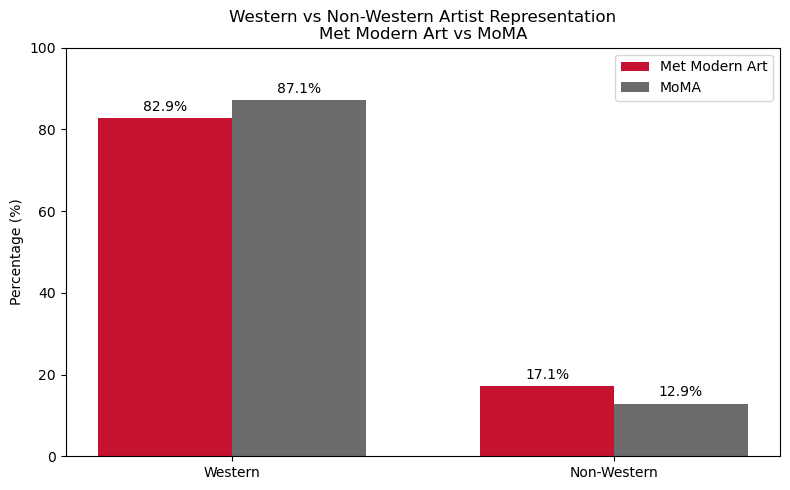

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

categories = ["Western", "Non-Western"]
met_vals = [82.9, 17.1]
moma_vals = [87.1, 12.9]

x = range(len(categories))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], met_vals, width,
               label="Met Modern Art", color="#C41230")
bars2 = ax.bar([i + width/2 for i in x], moma_vals, width,
               label="MoMA", color="#6B6B6B")

ax.set_ylabel("Percentage (%)")
ax.set_title("Western vs Non-Western Artist Representation\nMet Modern Art vs MoMA")
ax.set_xticks(list(x))
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 100)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
        f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("chart1_representation.png", dpi=150)
plt.show()

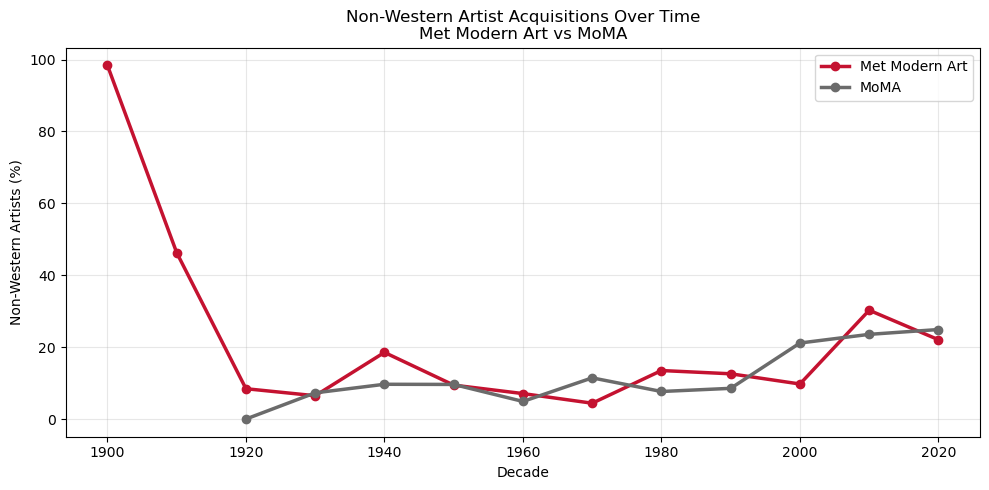

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(met_trend["Decade"], met_trend["NonWestern_Pct"],
        color="#C41230", marker="o", linewidth=2.5, label="Met Modern Art")
ax.plot(moma_trend["Decade"], moma_trend["NonWestern_Pct"],
        color="#6B6B6B", marker="o", linewidth=2.5, label="MoMA")

ax.set_xlabel("Decade")
ax.set_ylabel("Non-Western Artists (%)")
ax.set_title("Non-Western Artist Acquisitions Over Time\nMet Modern Art vs MoMA")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chart2_trend.png", dpi=150)
plt.show()
                       

In [ ]:
# == Line chart - Non-Western % over time by decade, both institutions == 
# 1. 1900 spike on Met line is an outlier - likely a small number of objects with unusual provenance skewing early percentage
# 2. Key story - from 2000 onwards, both lines converge and rise together, with the Met pulling slightly ahead in the 2010's, likely due to Tang Wing narrative
# 3. Lines converging in 2020 suggest industry-wide momentum in Non-Western aquisitions

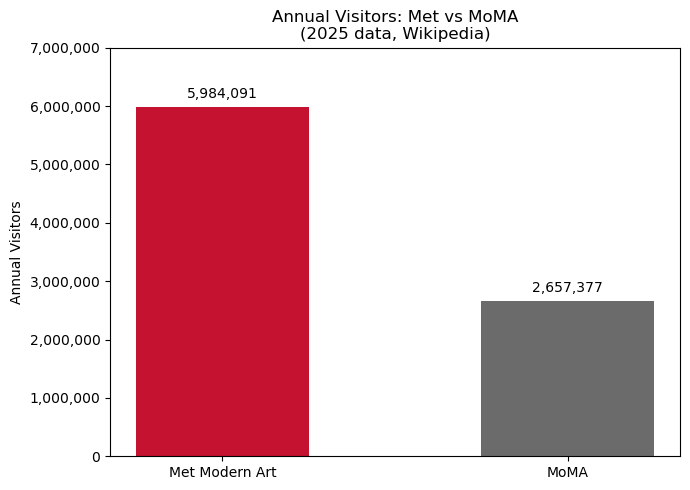

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

museums = ["Met Modern Art", "MoMA"]
visitors = [5984091, 2657377]
colors = ["#C41230", "#6B6B6B"]

bars = ax.bar(museums, visitors, color=colors, width=0.5)

ax.set_ylabel("Annual Visitors")
ax.set_title("Annual Visitors: Met vs MoMA\n(2025 data, Wikipedia)")
ax.set_ylim(0, 7000000)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
            f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("chart3_visitors.png", dpi=150)
plt.show()